## Binomial distribution Option pricing model 
The goal is to calculate the today option price 

- $S$ Input stock current price 
-  $K$ Option strike price 
-  $r$ Risk free interest 
-  $\sigma$ Volatiltiy 
-  $t$ Time to maturity |
-  $n$ Number of steps 
-  


In [1]:
# European call option pricing
import math

def biomial_option_price(S0, K, r, sigma, T, N):
    # calculate time step and tree parameters 
    dt = T / N
    u = math.exp(sigma * math.sqrt(dt))  # up factor
    d = 1/u
    p = (math.exp(r * dt) - d) / (u - d)  # risk-neutral probability
    discount = math.exp(-r * dt)
    
    # Initialise asset prices at maturity 
    stock_prices = [0] * (N + 1)
    option_values = [0] * (N + 1)
    
    for j in range(N+1):
        stock_prices[j] = S0 * (u ** (N-j)) * (d * j)
        option_values[j] = max(0, stock_prices[j] - K,0)  # payoff at maturity
    
    for i in range(N-1, -1, -1):
        for j in range(i+1):
            option_values[j] = discount * (p * option_values[j] + (1-p) * option_values[j+1])
            
    return option_values[0]


price = biomial_option_price(S0=100, K=100, r=0.05, sigma=0.2, T=1, N=100)
print(f"The price of the European call option is: {price:.2f}")
            


The price of the European call option is: 12510.24


Fetching real-world data for GOOGL...

--- Market Data Loaded ---
Stock Price (S0):   $396.78
Strike Price (K):   $397.50
Risk-Free Rate (r): 3.59%
Implied Vol (σ):    23.30%
Market Bid Price:   $2.50
Market Ask Price:   $3.00
--------------------------

Model Calculated Valuation Today: $10.70


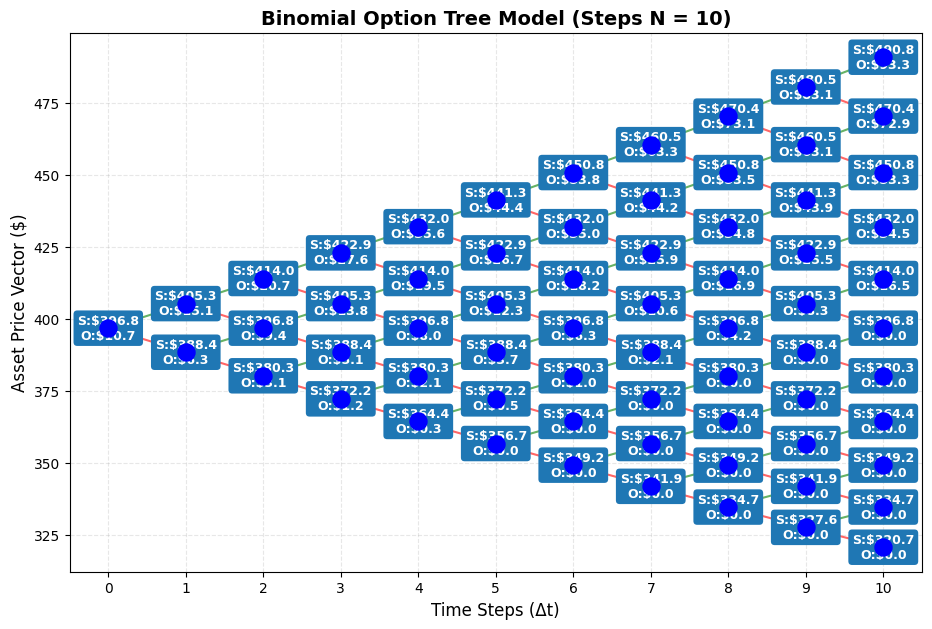

In [2]:
import matplotlib.pyplot as plt
import yfinance as yf

def fetch_live_option_data(ticker_symbol):
    """Pulls live stock price, risk-free rate, and ATM option parameters from Yahoo Finance."""
    print(f"Fetching real-world data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)

    # 1. Get live stock price
    hist = ticker.history(period="1d")
    if hist.empty:
        raise ValueError(f"Ticker '{ticker_symbol}' not found.")
    S0 = hist["Close"].iloc[-1]

    # 2. Get closest option expiration date
    expirations = ticker.options
    if not expirations:
        raise ValueError("No options data available for this ticker.")
    target_expiry = expirations[0]  # Closest expiration date

    # 3. Pull option chain and isolate an At-The-Money Call option
    opt_chain = ticker.option_chain(target_expiry)
    calls = opt_chain.calls.copy()

    # Find the strike price closest to current stock price
    calls["diff"] = (calls["strike"] - S0).abs()
    atm_option = calls.sort_values(by="diff").iloc[0]

    K = atm_option["strike"]
    sigma = atm_option["impliedVolatility"]

    # Fallback proxy if implied volatility data is zero
    if sigma <= 0:
        sigma = 0.25

    # 4. Fetch the 13-week US Treasury Bill yield as the Risk-Free Rate proxy
    try:
        r = yf.Ticker("^IRX").history(period="1d")["Close"].iloc[-1] / 100
    except Exception:
        r = 0.045  # Standard fallback if macroeconomic feed fails

    # 5. Approximate time to expiration in years (assuming roughly 1 month)
    T = 1 / 12

    print("\n--- Market Data Loaded ---")
    print(f"Stock Price (S0):   ${S0:.2f}")
    print(f"Strike Price (K):   ${K:.2f}")
    print(f"Risk-Free Rate (r): {r*100:.2f}%")
    print(f"Implied Vol (σ):    {sigma*100:.2f}%")
    print(f"Market Bid Price:   ${atm_option['bid']:.2f}")
    print(f"Market Ask Price:   ${atm_option['ask']:.2f}")
    print("--------------------------\n")

    return S0, K, r, sigma, T, atm_option["lastPrice"]


def build_and_plot_binomial_tree(S0, K, r, sigma, T, N=3):
    """Calculates pricing matrix and visually renders the mathematical tree layout."""
    # Compute parameters
    dt = T / N
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    p = (math.exp(r * dt) - d) / (u - d)
    discount = math.exp(-r * dt)

    stock_tree = {}
    option_tree = {}

    # Step 1: Generate forward stock prices
    # i = time step, j = number of up moves
    for i in range(N + 1):
        for j in range(i + 1):
            stock_tree[(i, j)] = S0 * (u**j) * (d ** (i - j))

    # Step 2: Calculate backward option payoffs (American Call Logic)
    for j in range(N + 1):
        option_tree[(N, j)] = max(stock_tree[(N, j)] - K, 0)

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            future_up = option_tree[(i + 1, j + 1)]
            future_down = option_tree[(i + 1, j)]
            continuation_val = discount * (p * future_up + (1 - p) * future_down)

            # Check if early exercise is worth more (American Option property)
            exercise_val = max(stock_tree[(i, j)] - K, 0)
            option_tree[(i, j)] = max(continuation_val, exercise_val)

    # Step 3: Draw the tree structure using Matplotlib
    plt.figure(figsize=(11, 7))

    # Plot branches
    for i in range(N):
        for j in range(i + 1):
            x_start, y_start = i, stock_tree[(i, j)]

            # Up branch
            x_up, y_up = i + 1, stock_tree[(i + 1, j + 1)]
            plt.plot([x_start, x_up], [y_start, y_up], "g-", alpha=0.6, lw=1.5)

            # Down branch
            x_down, y_down = i + 1, stock_tree[(i + 1, j)]
            plt.plot(
                [x_start, x_down], [y_start, y_down], "r-", alpha=0.6, lw=1.5
            )

    # Plot nodes and annotations
    for (i, j), S_val in stock_tree.items():
        O_val = option_tree[(i, j)]
        plt.scatter(i, S_val, color="blue", s=150, zorder=5)

        # Labels for Stock price (S) and Option value (O) inside the node
        label = f"S:${S_val:.1f}\nO:${O_val:.1f}"
        plt.text(
            i,
            S_val,
            label,
            ha="center",
            va="center",
            fontsize=9,
            color="white",
            weight="bold",
            bbox=dict(
                facecolor="#1f77b4", edgecolor="none", boxstyle="round,pad=0.3"
            ),
        )

    plt.title(
        f"Binomial Option Tree Model (Steps N = {N})",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Time Steps (Δt)", fontsize=12)
    plt.ylabel("Asset Price Vector ($)", fontsize=12)
    plt.xticks(range(N + 1))
    plt.grid(True, linestyle="--", alpha=0.3)

    print(f"Model Calculated Valuation Today: ${option_tree[(0,0)]:.2f}")
    plt.show()


# --- EXECUTION ---
if __name__ == "__main__":
    # You can change "AAPL" to "MSFT", "NVDA", or "TSLA"
    try:
        S0, K, r, sigma, T, market_price = fetch_live_option_data("GOOGL")

        # Keep N small (3-5) for visual layouts so text labels don't blend together.
        # If calculating pure valuation precision without charting, N can be set to 100+.
        build_and_plot_binomial_tree(S0, K, r, sigma, T, N=10)

    except Exception as e:
        print(f"Execution Error: {e}")